# Exercise Sheet 3
### Name: Aryan Varshneya
### Matriculation Number: 261678

In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install numpy
!pip install matplotlib pillow


[notice] A new release of pip is available: 26.0 -> 26.1.2
[notice] To update, run: C:\Users\aaial\anaconda3\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0 -> 26.1.2
[notice] To update, run: C:\Users\aaial\anaconda3\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0 -> 26.1.2
[notice] To update, run: C:\Users\aaial\anaconda3\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0 -> 26.1.2
[notice] To update, run: C:\Users\aaial\anaconda3\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0 -> 26.1.2
[notice] To update, run: C:\Users\aaial\anaconda3\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0 -> 26.1.2
[notice] To update, run: C:\Users\aaial\anaconda3\python.exe -m pip install --upgrade pip


In [2]:
import zipfile
import os

zip_files = [
    'dataset/train.zip',
    'dataset/test.zip',
    'dataset/validation.zip',
    'dataset/test-fog.zip',
    'dataset/test-night.zip',
    'dataset/test-town-01.zip'
]

for file in zip_files:

    if os.path.exists(file):

        with zipfile.ZipFile(file, 'r') as zip_ref:

            zip_ref.extractall('dataset')

        print(f'Extracted: {file}')

    else:

        print(f'File not found: {file}')

print("All extraction complete.")

Extracted: dataset/train.zip
Extracted: dataset/test.zip
Extracted: dataset/validation.zip
Extracted: dataset/test-fog.zip
Extracted: dataset/test-night.zip
Extracted: dataset/test-town-01.zip
All extraction complete.


In [4]:
import torch
import torch.nn as nn
from torchvision import models

In [5]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cuda


In [6]:
import pandas as pd

train_labels = pd.read_csv("dataset/train/train/labels.csv")
train_labels.head()
#train_labels.tail()


,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,False,True,0,0,85
1,10,False,True,True,14,301,1138
2,20,True,True,True,99,196,517
3,30,True,True,True,99,181,530
4,40,True,True,True,101,169,538


In [7]:
print("Train images:", len(pd.read_csv("dataset/train/train/labels.csv")))
print("Test images:", len(pd.read_csv("dataset/test/test/labels.csv")))

Train images: 7200
Test images: 3600


In [8]:
print(train_labels['has_traffic_light'].value_counts())
print(train_labels['has_pedestrian'].value_counts())
print(train_labels['has_vehicle'].value_counts())

#print()
#print(train_labels[['has_traffic_light','has_pedestrian','has_vehicle']].value_counts())

has_traffic_light
True     5276
False    1924
Name: count, dtype: int64
has_pedestrian
False    5482
True     1718
Name: count, dtype: int64
has_vehicle
True     5458
False    1742
Name: count, dtype: int64


In [9]:
import os #path fix

os.getcwd()
#c:\\Users\\aaial\\Desktop\\OVGU\\Semester 1\\MLS\\Github\\ovgu-sem1-mlsafety


'c:\\Users\\aaial\\Desktop\\OVGU\\Semester 1\\MLS\\Github\\ovgu-sem1-mlsafety'

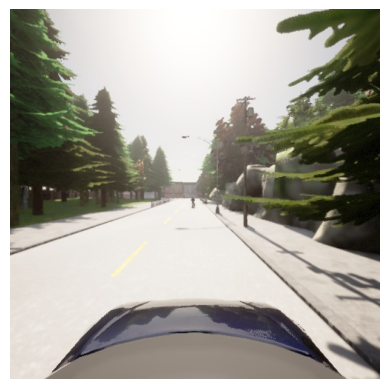

In [10]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open('dataset/train/rgb-front/000000.jpg')

plt.imshow(img)
plt.axis('off')
plt.show()

In [11]:
train_labels.head()

,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,False,True,0,0,85
1,10,False,True,True,14,301,1138
2,20,True,True,True,99,196,517
3,30,True,True,True,99,181,530
4,40,True,True,True,101,169,538


In [12]:
sample_rows = train_labels.sample(5)
sample_rows.head()


,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
5071,50710,True,False,True,336,0,124
758,7580,False,False,False,0,0,0
5458,54580,True,False,True,71,0,10651
386,3860,True,False,True,50,0,2288
1766,17660,False,False,False,0,0,0


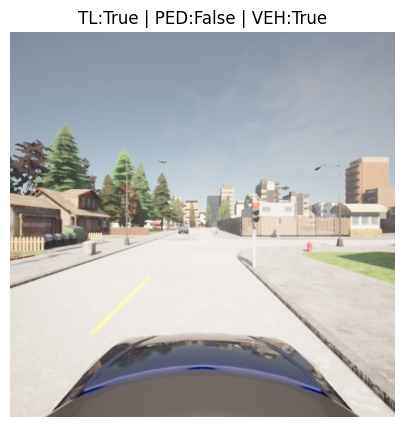

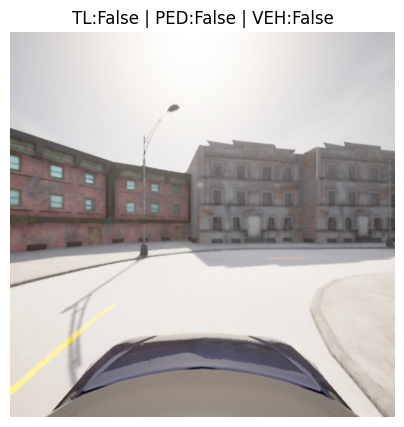

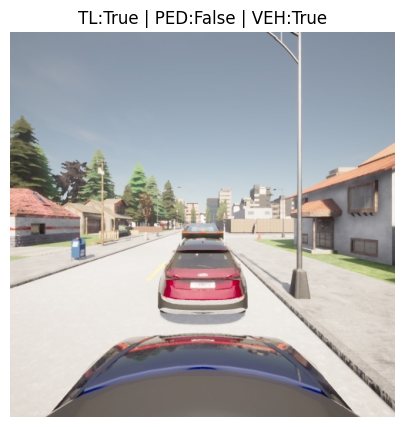

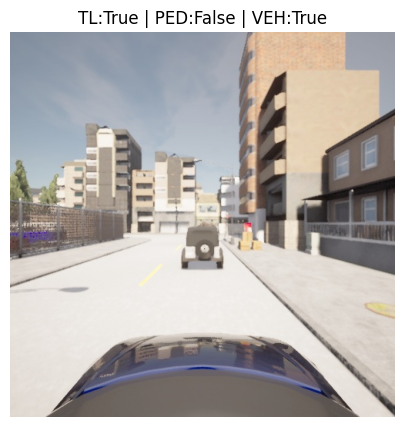

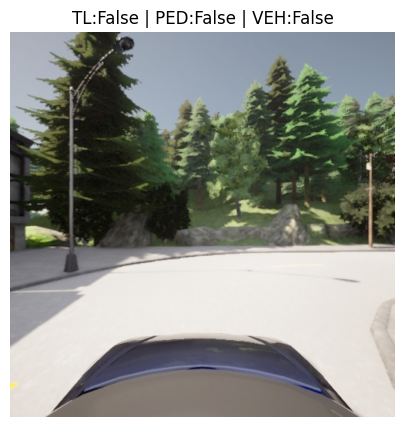

In [13]:
for _, row in sample_rows.iterrows():

    frame = str(row['frame']).zfill(6)
    
    img = Image.open(f'dataset/train/rgb-front/{frame}.jpg')

    plt.figure(figsize=(5,5))
    plt.imshow(img)

    title = f"TL:{row['has_traffic_light']} | PED:{row['has_pedestrian']} | VEH:{row['has_vehicle']}"
    
    plt.title(title)

    plt.axis('off')
    plt.show()

# Exercise 3.5: Train Three Binary Classifiers


In [14]:
pip install torch torchvision

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import torch
import torchvision

print(torch.__version__)

2.11.0+cu128


In [16]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader

from PIL import Image

import pandas as pd
import matplotlib.pyplot as plt

PyTorch Dataset

This class:

loads images
loads labels
converts image → tensor
returns:

In [17]:
class CarlaDataset(Dataset):

    def __init__(self, csv_file, img_dir, label_column, transform=None):

        self.labels = pd.read_csv(csv_file)

        self.img_dir = img_dir

        self.label_column = label_column

        self.transform = transform


    def __len__(self):

        return len(self.labels)


    def __getitem__(self, idx):

        row = self.labels.iloc[idx]

        frame = str(row['frame']).zfill(6)

        img_path = f"{self.img_dir}/{frame}.jpg"

        image = Image.open(img_path).convert("RGB")

        label = float(row[self.label_column])


        if self.transform:

            image = self.transform(image)

        return image, torch.tensor(label)

define image transformations.
Neural networks cannot directly use raw images.
We must:

resize them
convert to tensors
normalize them

Why 224×224?
Because ResNet18 expects that size.

In [18]:
transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# train the vehicle classifier

create datasets

In [19]:
train_dataset = CarlaDataset(

    csv_file='dataset/train/labels.csv',

    img_dir='dataset/train/rgb-front',

    label_column='has_vehicle',

    transform=transform
)

val_dataset = CarlaDataset(

    csv_file='dataset/validation/labels.csv',

    img_dir='dataset/validation/rgb-front',

    label_column='has_vehicle',

    transform=transform
)

create dataloaders

This prepares batches for training.

In [20]:
train_loader = DataLoader(

    train_dataset,

    batch_size=32,

    shuffle=True
)

val_loader = DataLoader(

    val_dataset,

    batch_size=32,

    shuffle=False
)

load ResNet18 and load already trained on ImageNet

In [21]:
model = models.resnet18(pretrained=True)

c:\Users\aaial\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\aaial\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Now replace final layer:
because, Original ResNet predicts 1000 classes.

In [22]:
model.fc = nn.Linear(model.fc.in_features, 1)

Binary Cross Entropy loss
Adam optimizer
learning rate = 0.001

In [38]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
model = model.to(device)

In [39]:
model = model.to(device)

In [40]:
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(

    model.parameters(),

    lr=0.001
)

Now move model to device:

## actual training

In [41]:
print(device)
print(next(model.parameters()).device)

cuda
cuda:0


In [42]:
train_losses = []
val_losses = []

epochs = 5

for epoch in range(epochs):

    model.train()

    running_loss = 0.0


    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.to(device).unsqueeze(1)


        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()


        running_loss += loss.item()


    train_loss = running_loss / len(train_loader)

    train_losses.append(train_loss)


    model.eval()

    val_running_loss = 0.0


    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            labels = labels.to(device).unsqueeze(1)


            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()


    val_loss = val_running_loss / len(val_loader)

    val_losses.append(val_loss)
    

    print(f"Epoch {epoch+1}/{epochs}")

    print(f"Train Loss: {train_loss:.4f}")

    print(f"Validation Loss: {val_loss:.4f}")

Epoch 1/5
Train Loss: 0.2671
Validation Loss: 0.3092
Epoch 2/5
Train Loss: 0.2067
Validation Loss: 0.3351
Epoch 3/5
Train Loss: 0.1854
Validation Loss: 0.3076
Epoch 4/5
Train Loss: 0.1577
Validation Loss: 0.3056
Epoch 5/5
Train Loss: 0.1457
Validation Loss: 0.3018


Epoch 1/5
Train Loss: 0.2671
Validation Loss: 0.3092

Epoch 2/5
Train Loss: 0.2067
Validation Loss: 0.3351

Epoch 3/5
Train Loss: 0.1854
Validation Loss: 0.3076

Epoch 4/5
Train Loss: 0.1577
Validation Loss: 0.3056

Epoch 5/5
Train Loss: 0.1457
Validation Loss: 0.3018

1. Training loss continuously decreases:
2. model is learning patterns.
3. Validation loss also generally decreases.
4. spike in epoch 2 is normal sometimes due to:
batch variation, optimizer updates, early instability

In [44]:
torch.save(
    model.state_dict(),
    "vehicle_model.pth"
)

print("Vehicle model saved")

Vehicle model saved


Now we plot plot the losses.

In [45]:
print(train_losses)
print(val_losses)

print("Train points:", len(train_losses))
print("Val points:", len(val_losses))

[0.2671012910207113, 0.20673121790091198, 0.18539478085107275, 0.15768822320633463, 0.14568893861439494]
[0.3092468258602451, 0.33511527679552555, 0.30762750851139153, 0.3055557089156432, 0.30175758217395987]
Train points: 5
Val points: 5


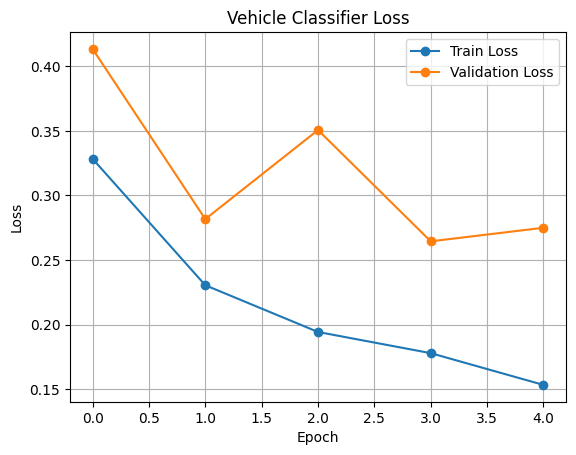

In [46]:
# plt.plot(train_losses, label='Train Loss')

# plt.plot(val_losses, label='Validation Loss')

# plt.xlabel('Epoch')

# plt.ylabel('Loss')

# plt.title('Vehicle Classifier Loss')

# plt.legend()

# plt.show()

train_losses = [0.3284, 0.2305, 0.1943, 0.1779, 0.1533]

val_losses = [0.4135, 0.2817, 0.3507, 0.2645, 0.2750]

plt.plot(train_losses, marker='o', label='Train Loss')
plt.plot(val_losses, marker='o', label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Vehicle Classifier Loss')
plt.legend()
plt.grid(True)

plt.show()

# 2. train the Pedestrian classifier

In [47]:
print(device)
print(next(model.parameters()).device)

cuda
cuda:0


In [48]:
train_dataset = CarlaDataset(

    csv_file='dataset/train/train/labels.csv',

    img_dir='dataset/train/train/rgb-front',

    label_column='has_pedestrian',

    transform=transform
)

val_dataset = CarlaDataset(

    csv_file='dataset/validation/validation/labels.csv',

    img_dir='dataset/validation/validation/rgb-front',

    label_column='has_pedestrian',

    transform=transform
)



In [49]:
train_loader = DataLoader(

    train_dataset,

    batch_size=32,

    shuffle=True
)

val_loader = DataLoader(

    val_dataset,

    batch_size=32,

    shuffle=False
)

### reinitialize model again:

In [50]:
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 1)
model = model.to(device)

In [51]:
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(

    model.parameters(),

    lr=0.001
)

In [52]:
train_losses = []
val_losses = []

epochs = 5

for epoch in range(epochs):

    model.train()

    running_loss = 0.0


    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.to(device).unsqueeze(1)


        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()


        running_loss += loss.item()


    train_loss = running_loss / len(train_loader)

    train_losses.append(train_loss)


    model.eval()

    val_running_loss = 0.0


    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            labels = labels.to(device).unsqueeze(1)


            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()


    val_loss = val_running_loss / len(val_loader)

    val_losses.append(val_loss)


    print(f"Epoch {epoch+1}/{epochs}")

    print(f"Train Loss: {train_loss:.4f}")

    print(f"Validation Loss: {val_loss:.4f}")

Epoch 1/5
Train Loss: 0.5266
Validation Loss: 0.5905
Epoch 2/5
Train Loss: 0.4272
Validation Loss: 0.5452
Epoch 3/5
Train Loss: 0.3746
Validation Loss: 0.6336
Epoch 4/5
Train Loss: 0.3216
Validation Loss: 0.6895
Epoch 5/5
Train Loss: 0.2750
Validation Loss: 0.7733


In [53]:
torch.save(
    model.state_dict(),
    "pedestrian_model.pth"
)

print("Pedestrian model saved")

Pedestrian model saved


### plot

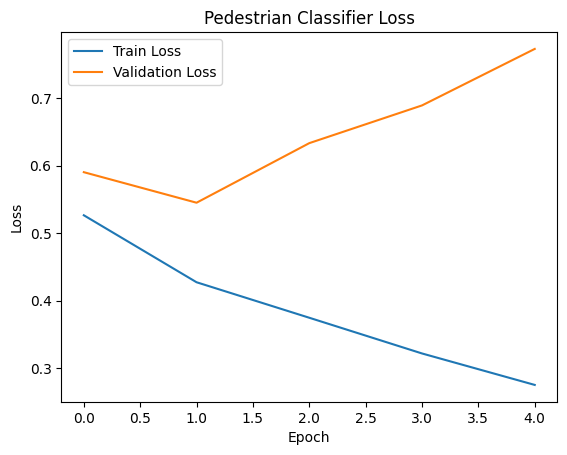

In [54]:
plt.plot(train_losses, label='Train Loss')

plt.plot(val_losses, label='Validation Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.title('Pedestrian Classifier Loss')

plt.legend()

plt.show()

# 3. train the Traffic Light classifier

In [55]:
train_dataset = CarlaDataset(

    csv_file='dataset/train/train/labels.csv',

    img_dir='dataset/train/train/rgb-front',

    label_column='has_traffic_light',

    transform=transform
)

val_dataset = CarlaDataset(

    csv_file='dataset/validation/validation/labels.csv',

    img_dir='dataset/validation/validation/rgb-front',

    label_column='has_traffic_light',

    transform=transform
)

In [56]:
train_loader = DataLoader(

    train_dataset,

    batch_size=32,

    shuffle=True
)

val_loader = DataLoader(

    val_dataset,

    batch_size=32,

    shuffle=False
)

### reinitialize model again:

In [57]:
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 1)
model = model.to(device)

In [58]:
print(device)
print(next(model.parameters()).device)

cuda
cuda:0


In [59]:
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(

    model.parameters(),

    lr=0.001
)

In [60]:
train_losses = []
val_losses = []

epochs = 5

for epoch in range(epochs):

    model.train()

    running_loss = 0.0


    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.to(device).unsqueeze(1)


        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()


        running_loss += loss.item()


    train_loss = running_loss / len(train_loader)

    train_losses.append(train_loss)


    model.eval()

    val_running_loss = 0.0


    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            labels = labels.to(device).unsqueeze(1)


            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()


    val_loss = val_running_loss / len(val_loader)

    val_losses.append(val_loss)


    print(f"Epoch {epoch+1}/{epochs}")

    print(f"Train Loss: {train_loss:.4f}")

    print(f"Validation Loss: {val_loss:.4f}")

Epoch 1/5
Train Loss: 0.1712
Validation Loss: 0.1164
Epoch 2/5
Train Loss: 0.0966
Validation Loss: 0.0855
Epoch 3/5
Train Loss: 0.0644
Validation Loss: 0.0771
Epoch 4/5
Train Loss: 0.0461
Validation Loss: 0.1006
Epoch 5/5
Train Loss: 0.0510
Validation Loss: 0.0665


In [61]:
torch.save(
    model.state_dict(),
    "traffic_light_model.pth"
)

print("Traffic Light model saved")

Traffic Light model saved


### plot

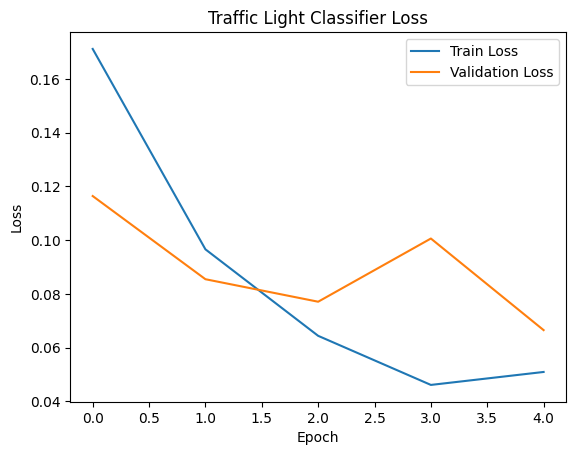

In [62]:
plt.plot(train_losses, label='Train Loss')

plt.plot(val_losses, label='Validation Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.title('Traffic Light Classifier Loss')

plt.legend()

plt.show()

# Exercise 3.6: Evaluation

install sklearn

In [63]:
!pip install scikit-learn


[notice] A new release of pip is available: 26.0 -> 26.1.2
[notice] To update, run: C:\Users\aaial\anaconda3\python.exe -m pip install --upgrade pip


In [64]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

create test dataset [vehicle classifier]

In [ ]:
test_dataset = CarlaDataset(

    csv_file='dataset/test/test/labels.csv',

    img_dir='dataset/test/test/rgb-front',

    label_column='has_vehicle',

    transform=transform
)

test_loader = DataLoader(

    test_dataset,

    batch_size=32,

    shuffle=False
)

evaluation code

This collects:
predictions
true labels

In [ ]:
model.eval()

all_preds = []

all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        preds = torch.sigmoid(outputs)

        preds = (preds > 0.5).float()

        all_preds.extend(preds.cpu().numpy())

        all_labels.extend(labels.numpy())

metrics

In [ ]:
accuracy = accuracy_score(all_labels, all_preds)

precision = precision_score(all_labels, all_preds)

recall = recall_score(all_labels, all_preds)

f1 = f1_score(all_labels, all_preds)

print("Accuracy:", accuracy)

print("Precision:", precision)

print("Recall:", recall)

print("F1-score:", f1)

In [65]:
import torch
import torchvision.models as models
import torch.nn as nn

def get_fc_mean(model_path):

    model = models.resnet18(weights=None)

    model.fc = nn.Linear(
        model.fc.in_features,
        1
    )

    model.load_state_dict(
        torch.load(
            model_path,
            map_location="cpu"
        )
    )

    return model.fc.weight.mean().item()

print(
    "Vehicle:",
    get_fc_mean("vehicle_model.pth")
)

print(
    "Pedestrian:",
    get_fc_mean("pedestrian_model.pth")
)

print(
    "Traffic Light:",
    get_fc_mean("traffic_light_model.pth")
)

Vehicle: 0.013296080753207207
Pedestrian: -0.004005124792456627
Traffic Light: 0.009168584831058979
